In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


data_set = pd.read_csv("drive/MyDrive/neural/hour.csv")

data_set = data_set.applymap(lambda x: x.strip() if isinstance(x, str) else x)

features = [
    'season', 'yr', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit',
    'temp', 'atemp', 'hum', 'windspeed'
]
target = ["cnt"]


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

x = scaler_X.fit_transform(data_set[features].values)
y = scaler_y.fit_transform(data_set[target].values)


class BikeDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.seq_len]
        y_target = self.y[idx + self.seq_len]
        return x_seq, y_target

SEQ_LEN = 12

dataset = BikeDataset(x, y, SEQ_LEN)


train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size

train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
test_dataset = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

/tmp/ipykernel_5280/3342268899.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_set = data_set.applymap(lambda x: x.strip() if isinstance(x, str) else x)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch 1/4, Train Loss: 0.014253 Val Loss: 0.029690
Epoch 2/4, Train Loss: 0.010770 Val Loss: 0.019523
Epoch 3/4, Train Loss: 0.008602 Val Loss: 0.015641
Epoch 4/4, Train Loss: 0.008382 Val Loss: 0.013035


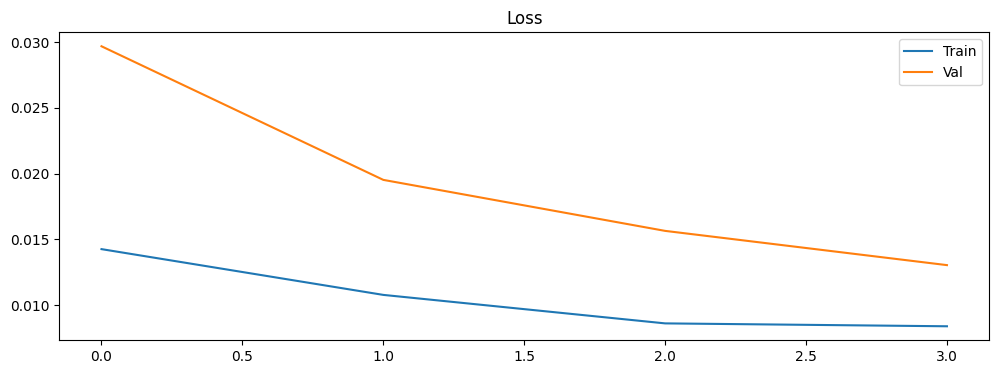

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


input_size = len(features)
hidden_size = 128
num_layers = 1
output_size = 1
seq_len = SEQ_LEN
dropout = 0.2


def val_err():
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            output = model(x_batch)
            preds.append(output.cpu().numpy())
            targets.append(y_batch.cpu().numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    from sklearn.metrics import mean_squared_error
    mse = mean_squared_error(targets, preds)

    return mse


class BikeRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, rnn_type="RNN"):
        super(BikeRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type

        if rnn_type == "RNN":
            self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                              batch_first=True, dropout=dropout)
        elif rnn_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers,
                               batch_first=True, dropout=dropout)
        elif rnn_type == "GRU":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers,
                              batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)

        if self.rnn_type == "LSTM":
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
            out, (hn, cn) = self.rnn(x, (h0, c0))
        else:
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
            out, hn = self.rnn(x, h0)

        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = BikeRNN(input_size, hidden_size, num_layers, output_size, rnn_type="GRU")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

num_epochs = 4
losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)
    mse = val_err()
    val_losses.append(mse)
    losses.append(train_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f} Val Loss: {mse:.6f}")

plt.figure(figsize=(12,4))
plt.plot(losses, label='Train')
plt.plot(val_losses, label='Val')

plt.legend()
plt.title('Loss')
plt.show()

Test MAE: 77.29, MSE: 12417.29, RMSE: 111.43


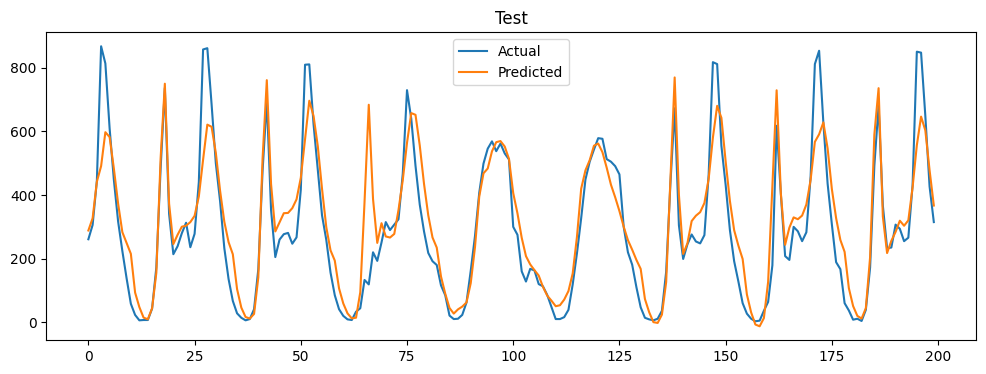

In [12]:
model.eval()
preds = []
targets = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model(x_batch)
        preds.append(output.numpy())
        targets.append(y_batch.numpy())

preds = np.vstack(preds)
targets = np.vstack(targets)

preds_inv = scaler_y.inverse_transform(preds)
targets_inv = scaler_y.inverse_transform(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(targets_inv, preds_inv)
mae = mean_absolute_error(targets_inv, preds_inv)
rmse = np.sqrt(mse)

print(f"Test MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(targets_inv[:200], label='Actual')
plt.plot(preds_inv[:200], label='Predicted')
plt.legend()
plt.title('Test')
plt.show()

Epoch 1/4, Train Loss: 0.014502  Val Loss: 0.027833
Epoch 2/4, Train Loss: 0.012403  Val Loss: 0.025025
Epoch 3/4, Train Loss: 0.011008  Val Loss: 0.024670
Epoch 4/4, Train Loss: 0.008637  Val Loss: 0.016477


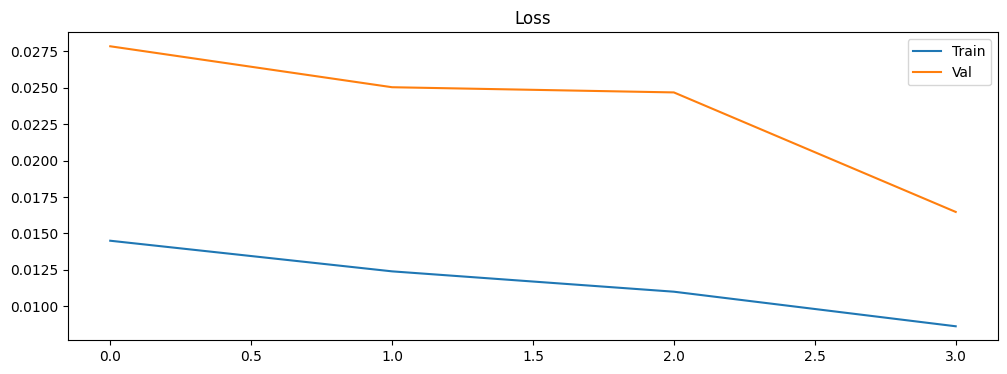

In [23]:
import numpy as np

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


def tanh(x):
    return np.tanh(x)

class Layer:
    def parameters(self):
        return []

    def grads(self):
        return []

class Linear(Layer):
    def __init__(self, in_features, out_features):
        k = 1.0 / np.sqrt(in_features)
        self.W = np.random.uniform(-k, k, (in_features, out_features))
        self.b = np.zeros(out_features)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = dout.sum(axis=0)
        dx = dout @ self.W.T
        return dx

    def parameters(self):
        return [self.W, self.b]

    def grads(self):
        return [self.dW, self.db]



class RNNCell(Layer):
    def __init__(self, input_size, hidden_size):
        k = 1.0 / np.sqrt(hidden_size)
        self.hidden_size = hidden_size
        self.W_ih = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hh = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b = np.zeros(hidden_size)
        self.dW_ih = np.zeros_like(self.W_ih)
        self.dW_hh = np.zeros_like(self.W_hh)
        self.db = np.zeros_like(self.b)
        self.cache = []

    def forward_step(self, x_t, h_prev):
        raw = x_t @ self.W_ih + h_prev @ self.W_hh + self.b
        h_t = tanh(raw)
        self.cache.append((x_t, h_prev, h_t))
        return h_t

    def backward_step(self, dh_t, cache_entry):
        x_t, h_prev, h_t = cache_entry
        draw = dh_t * (1 - h_t ** 2)
        self.dW_ih += x_t.T @ draw
        self.dW_hh += h_prev.T @ draw
        self.db += draw.sum(axis=0)
        dx = draw @ self.W_ih.T
        dh_prev = draw @ self.W_hh.T
        return dx, dh_prev

    def reset_grads(self):
        self.dW_ih[:] = 0
        self.dW_hh[:] = 0
        self.db[:] = 0
        self.cache = []

    def parameters(self):
        return [self.W_ih, self.W_hh, self.b]

    def grads(self):
        return [self.dW_ih, self.dW_hh, self.db]


class LSTMCell(Layer):
    def __init__(self, input_size, hidden_size):
        k = 1.0 / np.sqrt(hidden_size)
        self.hidden_size = hidden_size
        self.W_if = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hf = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_f = np.zeros(hidden_size)
        self.W_ii = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hi = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_i = np.zeros(hidden_size)
        self.W_ig = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hg = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_g = np.zeros(hidden_size)
        self.W_io = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_ho = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_o = np.zeros(hidden_size)
        self.dW_if = np.zeros_like(self.W_if)
        self.dW_hf = np.zeros_like(self.W_hf)
        self.db_f = np.zeros_like(self.b_f)
        self.dW_ii = np.zeros_like(self.W_ii)
        self.dW_hi = np.zeros_like(self.W_hi)
        self.db_i = np.zeros_like(self.b_i)
        self.dW_ig = np.zeros_like(self.W_ig)
        self.dW_hg = np.zeros_like(self.W_hg)
        self.db_g = np.zeros_like(self.b_g)
        self.dW_io = np.zeros_like(self.W_io)
        self.dW_ho = np.zeros_like(self.W_ho)
        self.db_o = np.zeros_like(self.b_o)
        self.cache = []

    def forward_step(self, x_t, h_prev, c_prev):
        f = sigmoid(x_t @ self.W_if + h_prev @ self.W_hf + self.b_f)
        i = sigmoid(x_t @ self.W_ii + h_prev @ self.W_hi + self.b_i)
        g = tanh(x_t @ self.W_ig + h_prev @ self.W_hg + self.b_g)
        o = sigmoid(x_t @ self.W_io + h_prev @ self.W_ho + self.b_o)
        c_t = f * c_prev + i * g
        tanh_c = tanh(c_t)
        h_t = o * tanh_c
        self.cache.append((x_t, h_prev, c_prev, f, i, g, o, c_t, tanh_c))
        return h_t, c_t

    def backward_step(self, dh_t, dc_t, cache_entry):
        x_t, h_prev, c_prev, f, i, g, o, c_t, tanh_c = cache_entry

        do = dh_t * tanh_c
        dc = dc_t + dh_t * o * (1 - tanh_c ** 2)

        df = dc * c_prev
        di = dc * g
        dg = dc * i
        dc_prev = dc * f

        df_raw = df * f * (1 - f)
        di_raw = di * i * (1 - i)
        dg_raw = dg * (1 - g ** 2)
        do_raw = do * o * (1 - o)

        self.dW_if += x_t.T @ df_raw
        self.dW_hf += h_prev.T @ df_raw
        self.db_f += df_raw.sum(axis=0)

        self.dW_ii += x_t.T @ di_raw
        self.dW_hi += h_prev.T @ di_raw
        self.db_i += di_raw.sum(axis=0)

        self.dW_ig += x_t.T @ dg_raw
        self.dW_hg += h_prev.T @ dg_raw
        self.db_g += dg_raw.sum(axis=0)

        self.dW_io += x_t.T @ do_raw
        self.dW_ho += h_prev.T @ do_raw
        self.db_o += do_raw.sum(axis=0)

        dx = (
            df_raw @ self.W_if.T +
            di_raw @ self.W_ii.T +
            dg_raw @ self.W_ig.T +
            do_raw @ self.W_io.T
        )

        dh_prev = (
            df_raw @ self.W_hf.T +
            di_raw @ self.W_hi.T +
            dg_raw @ self.W_hg.T +
            do_raw @ self.W_ho.T
        )

        return dx, dh_prev, dc_prev

    def reset_grads(self):
        for attr in ['dW_if','dW_hf','db_f','dW_ii','dW_hi','db_i',
                      'dW_ig','dW_hg','db_g','dW_io','dW_ho','db_o']:
            getattr(self, attr)[:] = 0
        self.cache = []

    def parameters(self):
        return [self.W_if,self.W_hf,self.b_f,self.W_ii,self.W_hi,self.b_i,
                self.W_ig,self.W_hg,self.b_g,self.W_io,self.W_ho,self.b_o]

    def grads(self):
        return [self.dW_if,self.dW_hf,self.db_f,self.dW_ii,self.dW_hi,self.db_i,
                self.dW_ig,self.dW_hg,self.db_g,self.dW_io,self.dW_ho,self.db_o]


class GRUCell(Layer):
    def __init__(self, input_size, hidden_size):
        k = 1.0 / np.sqrt(hidden_size)
        self.hidden_size = hidden_size
        self.W_ir = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hr = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_r = np.zeros(hidden_size)
        self.W_iz = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hz = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_z = np.zeros(hidden_size)
        self.W_in = np.random.uniform(-k, k, (input_size, hidden_size))
        self.W_hn = np.random.uniform(-k, k, (hidden_size, hidden_size))
        self.b_n = np.zeros(hidden_size)
        self.dW_ir = np.zeros_like(self.W_ir)
        self.dW_hr = np.zeros_like(self.W_hr)
        self.db_r = np.zeros_like(self.b_r)
        self.dW_iz = np.zeros_like(self.W_iz)
        self.dW_hz = np.zeros_like(self.W_hz)
        self.db_z = np.zeros_like(self.b_z)
        self.dW_in = np.zeros_like(self.W_in)
        self.dW_hn = np.zeros_like(self.W_hn)
        self.db_n = np.zeros_like(self.b_n)
        self.cache = []

    def forward_step(self, x_t, h_prev):
        r = sigmoid(x_t @ self.W_ir + h_prev @ self.W_hr + self.b_r)
        z = sigmoid(x_t @ self.W_iz + h_prev @ self.W_hz + self.b_z)
        rh = r * h_prev
        n = tanh(x_t @ self.W_in + rh @ self.W_hn + self.b_n)
        h_t = (1 - z) * n + z * h_prev
        self.cache.append((x_t, h_prev, r, z, n, rh))
        return h_t

    def backward_step(self, dh_t, cache_entry):
        x_t, h_prev, r, z, n, rh = cache_entry

        dn = dh_t * (1 - z)
        dz = dh_t * (h_prev - n)
        dh_prev = dh_t * z

        dn_raw = dn * (1 - n ** 2)

        self.dW_in += x_t.T @ dn_raw
        self.dW_hn += rh.T @ dn_raw
        self.db_n += dn_raw.sum(axis=0)

        dx = dn_raw @ self.W_in.T
        drh = dn_raw @ self.W_hn.T

        dr = drh * h_prev
        dh_prev += drh * r

        dr_raw = dr * r * (1 - r)
        dz_raw = dz * z * (1 - z)

        self.dW_ir += x_t.T @ dr_raw
        self.dW_hr += h_prev.T @ dr_raw
        self.db_r += dr_raw.sum(axis=0)

        self.dW_iz += x_t.T @ dz_raw
        self.dW_hz += h_prev.T @ dz_raw
        self.db_z += dz_raw.sum(axis=0)

        dx += dr_raw @ self.W_ir.T
        dx += dz_raw @ self.W_iz.T

        dh_prev += dr_raw @ self.W_hr.T
        dh_prev += dz_raw @ self.W_hz.T

        return dx, dh_prev

    def reset_grads(self):
        for attr in ['dW_ir','dW_hr','db_r','dW_iz','dW_hz','db_z',
                      'dW_in','dW_hn','db_n']:
            getattr(self, attr)[:] = 0
        self.cache = []

    def parameters(self):
        return [self.W_ir,self.W_hr,self.b_r,self.W_iz,self.W_hz,self.b_z,
                self.W_in,self.W_hn,self.b_n]

    def grads(self):
        return [self.dW_ir,self.dW_hr,self.db_r,self.dW_iz,self.dW_hz,self.db_z,
                self.dW_in,self.dW_hn,self.db_n]


class CustomBikeRNN:
    def __init__(self, input_size, hidden_size, num_layers, output_size, rnn_type="RNN"):
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type
        self.cells = []
        for layer_idx in range(num_layers):
            in_sz = input_size if layer_idx == 0 else hidden_size
            if rnn_type == "RNN":
                self.cells.append(RNNCell(in_sz, hidden_size))
            elif rnn_type == "LSTM":
                self.cells.append(LSTMCell(in_sz, hidden_size))
            elif rnn_type == "GRU":
                self.cells.append(GRUCell(in_sz, hidden_size))
        self.fc = Linear(hidden_size, output_size)
        self.seq_len = 0

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        self.seq_len = seq_len
        h = [np.zeros((batch_size, self.hidden_size)) for _ in range(self.num_layers)]
        if self.rnn_type == "LSTM":
            c = [np.zeros((batch_size, self.hidden_size)) for _ in range(self.num_layers)]
        for t in range(seq_len):
            inp = x[:, t, :]
            for layer_idx, cell in enumerate(self.cells):
                if self.rnn_type == "LSTM":
                    h[layer_idx], c[layer_idx] = cell.forward_step(inp, h[layer_idx], c[layer_idx])
                else:
                    h[layer_idx] = cell.forward_step(inp, h[layer_idx])
                inp = h[layer_idx]
        return self.fc.forward(h[-1])

    def backward(self, dout):
        batch_size = dout.shape[0]
        dh_from_fc = self.fc.backward(dout)

        dh_time = [np.zeros((batch_size, self.hidden_size)) for _ in range(self.num_layers)]
        if self.rnn_type == "LSTM":
            dc_time = [np.zeros((batch_size, self.hidden_size)) for _ in range(self.num_layers)]

        for t in reversed(range(self.seq_len)):
            dh_layer = None

            for layer_idx in reversed(range(self.num_layers)):
                cell = self.cells[layer_idx]

                dh = dh_time[layer_idx]
                if dh_layer is not None:
                    dh = dh + dh_layer

                if layer_idx == self.num_layers - 1 and t == self.seq_len - 1:
                    dh = dh + dh_from_fc

                if self.rnn_type == "LSTM":
                    dx, dh_prev, dc_prev = cell.backward_step(
                        dh, dc_time[layer_idx], cell.cache[t]
                    )
                    dc_time[layer_idx] = dc_prev
                else:
                    dx, dh_prev = cell.backward_step(dh, cell.cache[t])

                dh_time[layer_idx] = dh_prev
                dh_layer = dx

    def parameters_and_grads(self):
        pairs = []
        for cell in self.cells:
            for p, g in zip(cell.parameters(), cell.grads()):
                pairs.append((p, g))
        for p, g in zip(self.fc.parameters(), self.fc.grads()):
            pairs.append((p, g))
        return pairs

    def reset_grads(self):
        for cell in self.cells:
            cell.reset_grads()
        self.fc.dW[:] = 0
        self.fc.db[:] = 0


class CustomMSELoss:
    def forward(self, pred, target):
        self.pred = pred
        self.target = target
        self.n = pred.shape[0]
        return np.mean((pred - target) ** 2)

    def backward(self):
        return 2.0 * (self.pred - self.target) / self.n


class CustomSGD:
    def __init__(self, params_and_grads_fn, lr=0.001):
        self.params_and_grads_fn = params_and_grads_fn
        self.lr = lr

    def step(self):
        for param, grad in self.params_and_grads_fn():
            param -= self.lr * grad


def predict_next(model, x_seq):
    output = model.forward(x_seq)
    result = float(output[0, 0])
    model.reset_grads()
    return result


def forecast_n_hours_known_future_X(
    model,
    x_scaled,
    y_scaled,
    scaler_y,
    start_idx,
    seq_len=12,
    horizon=24
):
    preds_scaled = []
    trues_scaled = []

    for t in range(start_idx, start_idx + horizon):
        x_window = x_scaled[t - seq_len: t]
        x_window_batch = x_window[np.newaxis, :, :].astype(np.float32)

        y_hat_s = predict_next(model, x_window_batch)
        preds_scaled.append(y_hat_s)

        if t < len(y_scaled):
            trues_scaled.append(float(y_scaled[t, 0]))
        else:
            trues_scaled.append(np.nan)

    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    trues_scaled = np.array(trues_scaled).reshape(-1, 1)

    preds = scaler_y.inverse_transform(preds_scaled).reshape(-1)
    trues = scaler_y.inverse_transform(
        np.nan_to_num(trues_scaled, nan=0.0)
    ).reshape(-1)
    trues[np.isnan(trues_scaled.reshape(-1))] = np.nan

    return preds, trues


class CustomAdam:
    def __init__(self, params_and_grads_fn, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params_and_grads_fn = params_and_grads_fn
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.m = None
        self.v = None

    def step(self):
        self.t += 1
        pairs = self.params_and_grads_fn()

        if self.m is None:
            self.m = [np.zeros_like(p) for p, _ in pairs]
            self.v = [np.zeros_like(p) for p, _ in pairs]

        lr_t = self.lr * (np.sqrt(1 - self.beta2 ** self.t) / (1 - self.beta1 ** self.t))

        for idx, (param, grad) in enumerate(pairs):
            self.m[idx] = self.beta1 * self.m[idx] + (1 - self.beta1) * grad
            self.v[idx] = self.beta2 * self.v[idx] + (1 - self.beta2) * grad ** 2
            param -= lr_t * self.m[idx] / (np.sqrt(self.v[idx]) + self.eps)




input_size = len(features)
hidden_size = 128
num_layers = 1
output_size = 1

SEQ_LEN = 24
lr = 0.001
batch_size = 64

custom_model = CustomBikeRNN(input_size, hidden_size, num_layers, output_size, rnn_type="LSTM")
custom_criterion = CustomMSELoss()
custom_optimizer = CustomAdam(custom_model.parameters_and_grads, lr=0.001)

num_epochs = 4
losses = []
val_losses = []

def val_err():
    preds = []
    targets = []
    for x_batch, y_batch in test_loader:
        xb = x_batch.numpy()
        yb = y_batch.numpy()
        output = custom_model.forward(xb)
        preds.append(output)
        targets.append(yb)
        custom_model.reset_grads()
    preds = np.vstack(preds)
    targets = np.vstack(targets)
    return np.mean((preds - targets) ** 2)

for epoch in range(num_epochs):
    train_loss = 0
    n_samples = 0

    for x_batch, y_batch in train_loader:
        xb = x_batch.numpy()
        yb = y_batch.numpy()

        custom_model.reset_grads()

        output = custom_model.forward(xb)
        loss = custom_criterion.forward(output, yb)

        dout = custom_criterion.backward()
        custom_model.backward(dout)

        custom_optimizer.step()

        train_loss += loss * xb.shape[0]
        n_samples += xb.shape[0]

    train_loss /= n_samples
    mse = val_err()
    losses.append(train_loss)
    val_losses.append(mse)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}  Val Loss: {mse:.6f}")

plt.figure(figsize=(12,4))
plt.plot(losses, label='Train')
plt.plot(val_losses, label='Val')

plt.legend()
plt.title('Loss')
plt.show()

Test MAE: 101.56, MSE: 18192.71, RMSE: 134.88


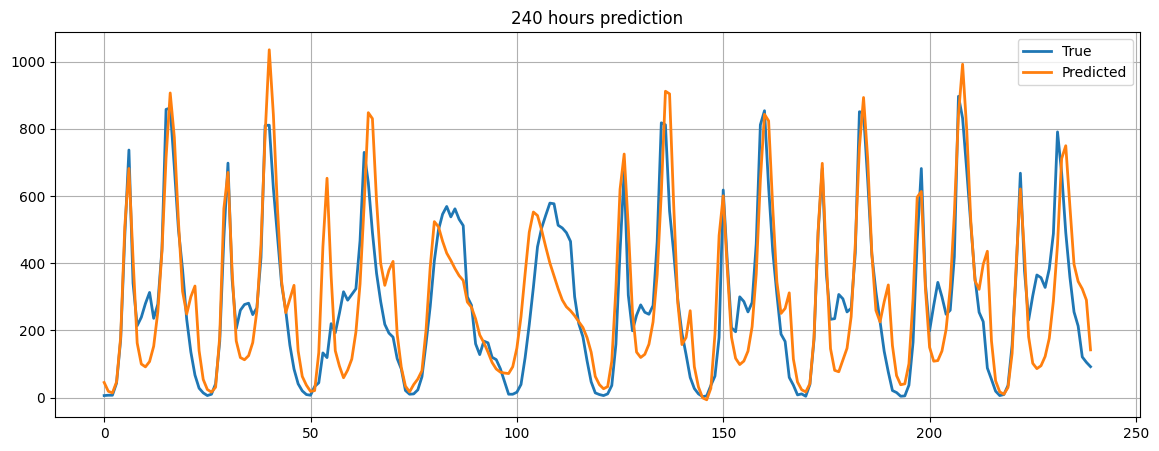

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt

start_idx = train_size + SEQ_LEN

HORIZON = 24*10

preds, trues = forecast_n_hours_known_future_X(
    model=custom_model,
    x_scaled=x,
    y_scaled=y,
    scaler_y=scaler_y,
    start_idx=start_idx,
    seq_len=SEQ_LEN,
    horizon=HORIZON
)

mse = mean_squared_error(trues, preds)
mae = mean_absolute_error(trues, preds)
rmse = np.sqrt(mse)

print(f"Test MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(trues, label="True", linewidth=2)
plt.plot(preds, label="Predicted", linewidth=2)
plt.title(f"{HORIZON} hours prediction")
plt.grid(True)
plt.legend()
plt.show()